In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib import rcParams
from scipy.interpolate import CubicSpline
rcParams.update({'figure.autolayout': True})
import os
import IPython

In [27]:
#The equation dy/dx = y^2 +1 
def q1_df(y,x=0):
    return y**2+1

### Euler's Method: $$y_{i+1} = y_i + \Delta x \times f(x_i,y_i)$$

In [35]:
# Euler's Method
# Input:
#   xi: initial value for x
#   yi: initial value for y
#   df: derivative function for f(y,x)
#   del_x: stepsize
#   steps: total steps
# Output:
#   result: 2d array of x and y values
def Euler(xi,yi,df,del_x,steps):
    step = steps+1
    x_array = np.zeros(step)
    y_array = np.zeros(step)
    for i in range(step):
        x_array[i] = xi
        y_array[i] = yi
        xi += del_x
        yi += del_x * df(yi,xi)
    result = np.stack((x_array,y_array))
    return result

### Runge Kutta 4: $$\begin{align} y_{i+1}&= y_i + \frac{h}{6} (k_1+2k_2+2k_3+k_4) \\ \text{where } k_1 &= f(y_i,x_i) \\ k_2 &= f(y_i+\frac{1}{2} h k_1,x_i+\frac{1}{2} h) \\k_3 &= f(y_i+\frac{1}{2} h k_2,x_i+\frac{1}{2} h) \\ k_4 &= f(y_i+ h k_3,x_i+h)\end{align}$$

In [65]:
# Runge-Kutta 4
# Input:
#   xi: initial value for x
#   yi: initial value for y
#   df: derivative function for f(y,x)
#   del_x: stepsize
#   steps: total steps
# Output:
#   result: 2d array of x and y values
def RK4(xi,yi,df,del_x,steps):
    step = steps+1
    x_array = np.zeros(step)
    y_array = np.zeros(step)
    h = del_x
    for i in range(step):
        x_array[i] = xi
        y_array[i] = yi
        k1 = df(yi,xi)
        k2 = df(yi+1/2*h*k1,xi+1/2*h)
        k3 = df(yi+1/2*h*k2,xi+1/2*h) 
        k4 = df(yi+h*k3,xi+h)
        xi += h
        yi += h/6*(k1+2*k2+2*k3+k4)
    result = np.stack((x_array,y_array))
    return result
      
    

In [ ]:
steps = 100
x_range = [0,2*np.pi]
x_vals = np.linspace(x_range[0],x_range[1],1000)
y_vals = np.tan(x_vals)
del_x = x_range[1]/steps
E_vals = Euler(x_vals[0],y_vals[0],q1_df,del_x,steps)
RK4_vals = RK4(x_vals[0],y_vals[0],q1_df,del_x,steps)

/var/folders/sm/sjz00q7943zdql3vzxcjy5rw0000gn/T/ipykernel_30700/2878056858.py:3: RuntimeWarning: overflow encountered in scalar power
  return y**2+1


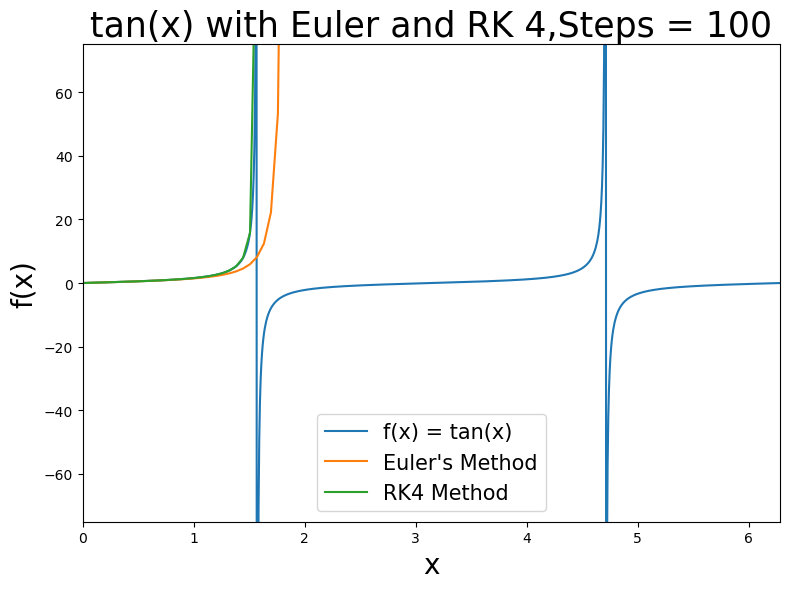

In [81]:
plt.rcParams["figure.figsize"] = (8,6)

plt.plot(x_vals,y_vals, label = "f(x) = tan(x)")
plt.plot(E_vals[0],E_vals[1], label = "Euler's Method")
plt.plot(RK4_vals[0],RK4_vals[1], label = "RK4 Method")

plt.xlabel("x",size= 20)
plt.ylabel("f(x)",size= 20)
plt.ylim(-75,75)
plt.xlim(0,2*np.pi)
plt.title("tan(x) with Euler and RK 4,Steps = %i"%steps,size= 25)
plt.legend(fontsize = 15);

### So the integration breaks at $\pi/2$. We will use that as the new limit.

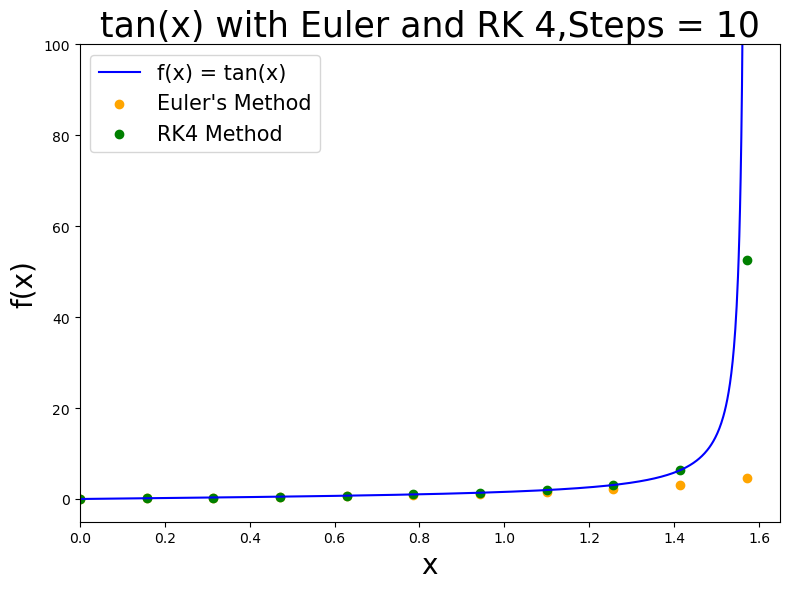

In [115]:
steps = 10
x_range = [0,1/2*np.pi]
x_vals = np.linspace(x_range[0],x_range[1],1000)
y_vals = np.tan(x_vals)
del_x = x_range[1]/steps
E_vals = Euler(x_vals[0],y_vals[0],q1_df,del_x,steps)
RK4_vals = RK4(x_vals[0],y_vals[0],q1_df,del_x,steps)
plt.rcParams["figure.figsize"] = (8,6)

plt.plot(x_vals,y_vals, c = "b",label = "f(x) = tan(x)")
plt.scatter(E_vals[0],E_vals[1], c = "orange",label = "Euler's Method")
plt.scatter(RK4_vals[0],RK4_vals[1], c = "green",label = "RK4 Method")

plt.xlabel("x",size= 20)
plt.ylabel("f(x)",size= 20)
plt.ylim(-5,100)
plt.xlim(0,1/2*np.pi*1.05)
plt.title("tan(x) with Euler and RK 4,Steps = %i"%steps,size= 25)
plt.legend(fontsize = 15);

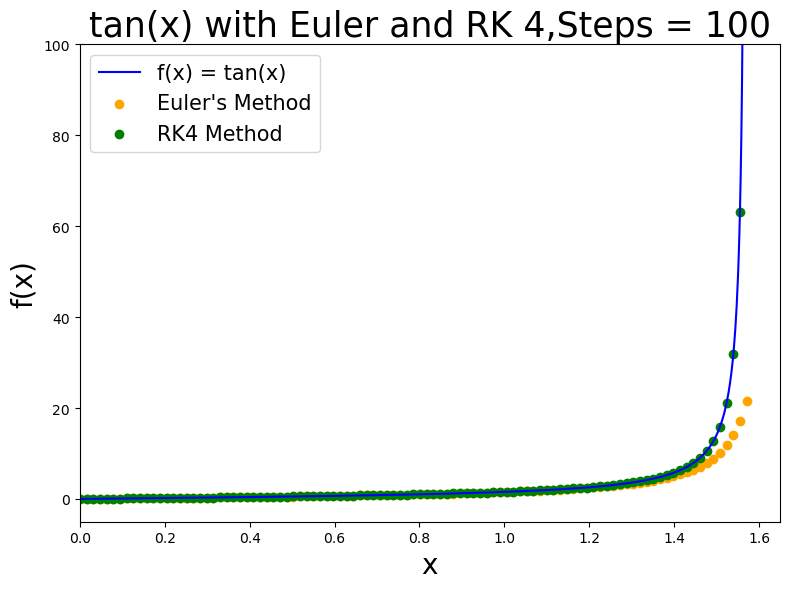

In [116]:
steps = 100
x_range = [0,1/2*np.pi]
x_vals = np.linspace(x_range[0],x_range[1],1000)
y_vals = np.tan(x_vals)
del_x = x_range[1]/steps
E_vals = Euler(x_vals[0],y_vals[0],q1_df,del_x,steps)
RK4_vals = RK4(x_vals[0],y_vals[0],q1_df,del_x,steps)
plt.rcParams["figure.figsize"] = (8,6)

plt.plot(x_vals,y_vals, c = "b",label = "f(x) = tan(x)")
plt.scatter(E_vals[0],E_vals[1], c = "orange",label = "Euler's Method")
plt.scatter(RK4_vals[0],RK4_vals[1], c = "green",label = "RK4 Method")

plt.xlabel("x",size= 20)
plt.ylabel("f(x)",size= 20)
plt.ylim(-5,100)
plt.xlim(0,1/2*np.pi*1.05)
plt.title("tan(x) with Euler and RK 4,Steps = %i"%steps,size= 25)
plt.legend(fontsize = 15);

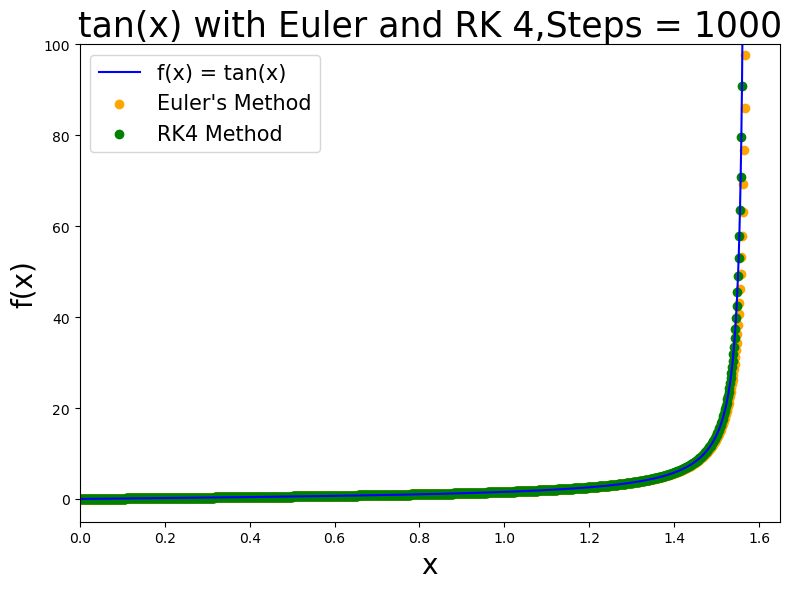

In [117]:
steps = int(1e3)
x_range = [0,1/2*np.pi]
x_vals = np.linspace(x_range[0],x_range[1],1000)
y_vals = np.tan(x_vals)
del_x = x_range[1]/steps
E_vals = Euler(x_vals[0],y_vals[0],q1_df,del_x,steps)
RK4_vals = RK4(x_vals[0],y_vals[0],q1_df,del_x,steps)
plt.rcParams["figure.figsize"] = (8,6)

plt.plot(x_vals,y_vals, c = "b",label = "f(x) = tan(x)")
plt.scatter(E_vals[0],E_vals[1], c = "orange",label = "Euler's Method")
plt.scatter(RK4_vals[0],RK4_vals[1], c = "green",label = "RK4 Method")

plt.xlabel("x",size= 20)
plt.ylabel("f(x)",size= 20)
plt.ylim(-5,100)
plt.xlim(0,1/2*np.pi*1.05)
plt.title("tan(x) with Euler and RK 4,Steps = %i"%steps,size= 25)
plt.legend(fontsize = 15);

In [149]:
steps = int(1e7)
x_range = [0,1/2*np.pi]
x_vals = np.linspace(x_range[0],x_range[1],1000)
y_vals = np.tan(x_vals)
del_x = x_range[1]/steps
E_vals = Euler(x_vals[0],y_vals[0],q1_df,del_x,steps)
RK4_vals = RK4(x_vals[0],y_vals[0],q1_df,del_x,steps)

In [150]:
E_max_y = E_vals[1][-1]
RK_max_y = RK4_vals[1][-1]

In [151]:
sample_s = 10
step_vals = np.logspace(1,6,sample_s,dtype = int)
RK_test_vals = np.zeros(sample_s)
E_test_vals = np.zeros(sample_s)
S_size_vals = np.zeros(sample_s)
n = 0
for i in (step_vals):
    del_x = x_range[1]/i
    Euler_temp = Euler(x_vals[0],y_vals[0],q1_df,del_x,i)
    RK_temp = RK4(x_vals[0],y_vals[0],q1_df,del_x,i)
    S_size_vals[n] = del_x
    E_test_vals[n] =  Euler_temp[1][-1]/E_max_y
    RK_test_vals[n] =  RK_temp[1][-1]/RK_max_y
    n+=1
conv_study = np.stack((S_size_vals,E_test_vals,RK_test_vals))
#conv_study = np.stack((step_vals,E_test_vals,RK_test_vals))

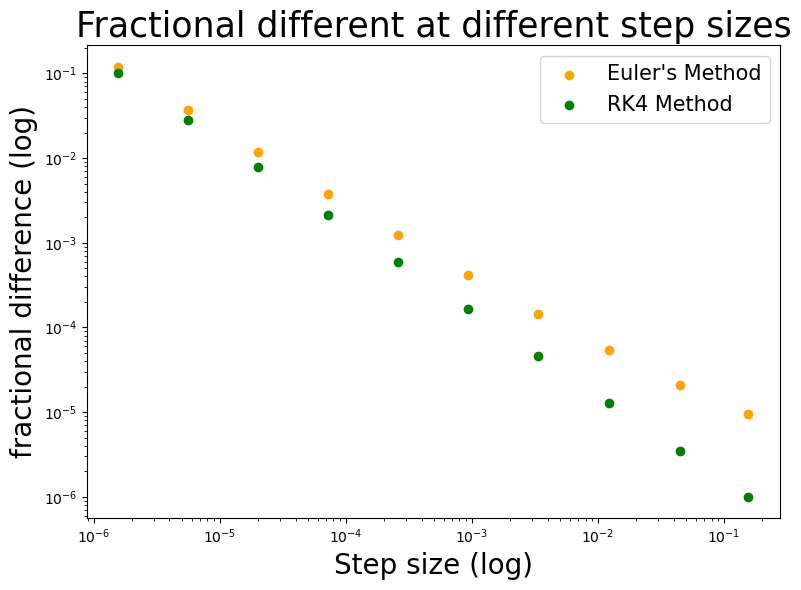

In [152]:
plt.rcParams["figure.figsize"] = (8,6)

plt.scatter(conv_study[0],conv_study[1], c = "orange",label = "Euler's Method")
plt.scatter(conv_study[0],conv_study[2], c = "green",label = "RK4 Method")

plt.xlabel("Step size (log)",size= 20)
plt.ylabel("fractional difference (log)",size= 20)
plt.yscale("log")
plt.xscale("log")
plt.title("Fractional different at different step sizes",size= 25)
plt.legend(fontsize = 15);

In [154]:
conv_study[1][-1], conv_study[2][-1]

(np.float64(0.11949963991545857), np.float64(0.10000016249681452))

In [ ]:
E_max_y/np.tan(1/2 np.pi)

316227.7660168379

In [156]:
np.tan(1/2*np.pi)

np.float64(1.633123935319537e+16)